In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [37]:
df = pd.read_csv("winequality.csv")


In [38]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [39]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [40]:
df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
610,8.8,0.24,0.54,2.5,0.083,25.0,57.0,0.99830,3.39,0.54,9.2,5
404,7.7,0.69,0.05,2.7,0.075,15.0,27.0,0.99740,3.26,0.61,9.1,5
534,10.0,0.48,0.24,2.7,0.102,13.0,32.0,1.00000,3.28,0.56,10.0,6
962,6.6,0.57,0.02,2.1,0.115,6.0,16.0,0.99654,3.38,0.69,9.5,5
943,9.8,0.50,0.34,2.3,0.094,10.0,45.0,0.99864,3.24,0.60,9.7,7


In [41]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [42]:
df.shape

(1599, 12)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [44]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [45]:
df.isnull()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,False,False,False,False,False,False,False,False,False,False,False,False
1595,False,False,False,False,False,False,False,False,False,False,False,False
1596,False,False,False,False,False,False,False,False,False,False,False,False
1597,False,False,False,False,False,False,False,False,False,False,False,False


In [46]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [47]:
df['quality'].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


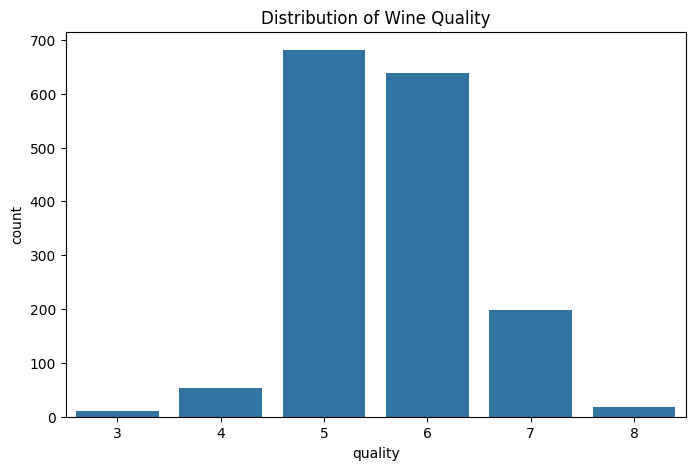

In [48]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=df)
plt.title("Distribution of Wine Quality")
plt.show()

In [49]:
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

In [50]:
df[['quality', 'quality_label']].head()

,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


In [51]:
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [53]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [54]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)


In [55]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)


In [56]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [57]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [58]:
svm = SVC()
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)


In [59]:
models = {
    "Logistic Regression": lr_pred,
    "KNN": knn_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "SVM": svm_pred
}

for model, pred in models.items():
    print(model, "Accuracy:", accuracy_score(y_test, pred))


Logistic Regression Accuracy: 0.865625
KNN Accuracy: 0.88125
Decision Tree Accuracy: 0.871875
Random Forest Accuracy: 0.9
SVM Accuracy: 0.875


In [60]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             param_grid={'svm__C': [0.1, 1, 10],
                         'svm__kernel': ['linear', 'rbf']})

In [61]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)


In [62]:
final_accuracy = accuracy_score(y_test, y_pred_best)
print("Final Test Accuracy:", final_accuracy)


Final Test Accuracy: 0.89375


In [63]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Tuned SVM (GridSearch + Pipeline)"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        final_accuracy
    ]
})



In [64]:
results = results.sort_values(by="Accuracy", ascending=False)
results


,Model,Accuracy
3,Random Forest,0.900000
5,Tuned SVM (GridSearch + Pipeline),0.893750
1,KNN,0.881250
4,SVM,0.875000
2,Decision Tree,0.871875
0,Logistic Regression,0.865625


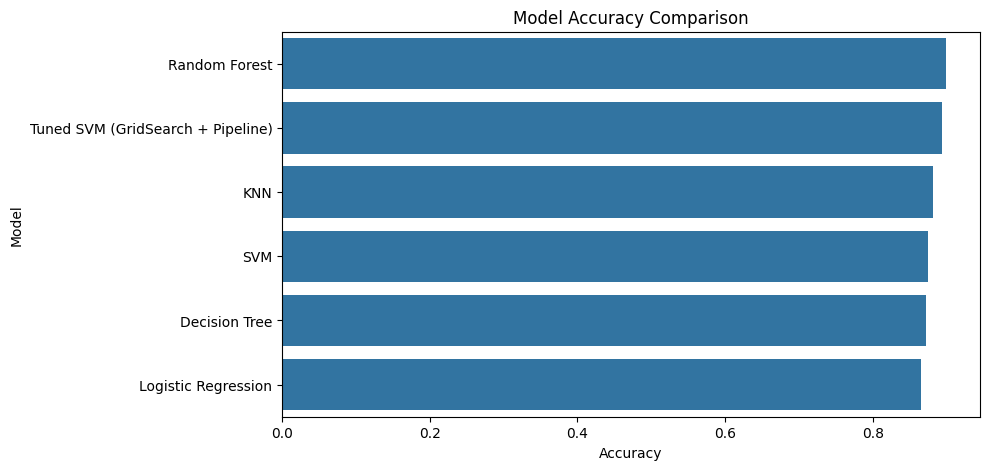

In [65]:
plt.figure(figsize=(9,5))
sns.barplot(x="Accuracy", y="Model", data=results)
plt.title("Model Accuracy Comparison")
plt.show()


In [66]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'svm__C': 10, 'svm__kernel': 'rbf'}
Best CV Score: 0.8944424019607844


In [67]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)


In [68]:
from sklearn.metrics import accuracy_score

final_accuracy = accuracy_score(y_test, y_pred_best)
print("Final Test Accuracy:", final_accuracy)


Final Test Accuracy: 0.89375


In [69]:


final_row = pd.DataFrame([{
    "Model": "Tuned SVM (GridSearch + Pipeline)",
    "Accuracy": final_accuracy
}])

results = pd.concat([results, final_row], ignore_index=True)
results.sort_values(by="Accuracy", ascending=False)


,Model,Accuracy
0,Random Forest,0.900000
1,Tuned SVM (GridSearch + Pipeline),0.893750
6,Tuned SVM (GridSearch + Pipeline),0.893750
2,KNN,0.881250
3,SVM,0.875000
4,Decision Tree,0.871875
5,Logistic Regression,0.865625


Multiple machine learning models were trained and evaluated on the wine quality dataset.
Among all models, the tuned Support Vector Machine using GridSearch and Pipeline achieved the highest accuracy of 89.37%.
Hyperparameter tuning helped improve model generalization and performance on unseen test data.

Conclusion:

In this project, we built an end-to-end machine learning system to predict wine quality using chemical properties.
Exploratory Data Analysis showed that most wines belong to average quality categories.
The problem was converted into a binary classification task to make it more practical.
Multiple machine learning models were trained and evaluated.
After hyperparameter tuning, Support Vector Machine with RBF kernel achieved the best performance.
This project helped me understand real-world ML workflows including preprocessing, model comparison, pipelines, and optimization, similar to industry-level ML applications.